# Wine Pairing Analysis
Analysis of wine and food pairing quality across 34,000+ combinations

**Tools:** Python, SQL, pandas, matplotlib

**Goal:** Identify which wine types pair best with different food categories

In [35]:
import pandas as pd
url = 'https://raw.githubusercontent.com/hammelltime/wine-pairing-analysis/main/wine_food_pairings.csv'
df = pd.read_csv(url)
df.head()  # Preview the first few rows

,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish,2,Poor,Heuristic pairing assessment.
1,Grenache,Red,charcuterie board,Salty Snack,French,3,Neutral,Heuristic pairing assessment.
2,Madeira,Fortified,lemon tart,Dessert,French,4,Good,Acidic wine balances acidic food.
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican,5,Excellent,Tannic red complements red meat fat.
4,Viognier,White,duck à l’orange,Poultry,Vietnamese,2,Poor,Heuristic pairing assessment.


In [36]:
len(df) # Number of rows

34933

In [37]:
import sqlite3

# Create a SQLite database (in memory - no file needed)
conn = sqlite3.connect(':memory:')

# Load your dataframe into the database as a table called 'wine_pairings'
df.to_sql('wine_pairings', conn, index=False, if_exists='replace')

# Test it - run a simple query
query = "SELECT * FROM wine_pairings LIMIT 5"
table = pd.read_sql(query, conn)
table

,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish,2,Poor,Heuristic pairing assessment.
1,Grenache,Red,charcuterie board,Salty Snack,French,3,Neutral,Heuristic pairing assessment.
2,Madeira,Fortified,lemon tart,Dessert,French,4,Good,Acidic wine balances acidic food.
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican,5,Excellent,Tannic red complements red meat fat.
4,Viognier,White,duck à l’orange,Poultry,Vietnamese,2,Poor,Heuristic pairing assessment.


In [38]:
# Determine if cuisine styles are evenly distributed

query = """
SELECT
    cuisine,
    COUNT(*) as num_cuisines,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM wine_pairings), 2) as percentage
FROM wine_pairings
GROUP BY cuisine
ORDER BY num_cuisines DESC
"""
cuisine_count = pd.read_sql(query, conn)
cuisine_count

# Yes, only a 3% increase from lowest total to highest

,cuisine,num_cuisines,percentage
0,Mexican,2089,5.98
1,Middle Eastern,2075,5.94
2,Thai,2071,5.93
3,Moroccan,2068,5.92
4,Chinese (Sichuan),2068,5.92
5,Vietnamese,2065,5.91
6,Indian,2062,5.90
7,Ethiopian,2059,5.89
8,Korean,2058,5.89
9,American BBQ,2049,5.87


In [39]:
# Determine if the food categories are evenly distributed

query = """
SELECT
  COUNT(*) as num_food_category, food_category,
  ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM wine_pairings), 2) as percentage
FROM wine_pairings
GROUP BY food_category
ORDER BY num_food_category DESC
"""
food_category_count = pd.read_sql(query, conn)
food_category_count

# No, significant differences. Red meat is far and away no. 1. Cheese and Acidic are also very high on the list.
# Unclear what foods are included in 'Acidic' food category

,num_food_category,food_category,percentage
0,8149,Red Meat,23.33
1,6691,Cheese,19.15
2,5597,Acidic,16.02
3,2448,Seafood,7.01
4,2020,Dessert,5.78
5,1785,Vegetarian,5.11
6,1530,Smoky BBQ,4.38
7,1530,Salty Snack,4.38
8,1507,Pork,4.31
9,1398,Creamy,4.00


In [40]:
# Determine what wine types are most food friendly (highest avg quality)
# Excluded dessert wines to focus on typical wine pairings of consumers

query = """
SELECT
    wine_type,
    food_category,
    AVG(pairing_quality) as avg_quality,
    COUNT(*) as num_pairings
FROM wine_pairings
WHERE food_category != 'Dessert'
GROUP BY wine_type, food_category
ORDER BY avg_quality DESC
LIMIT 25
"""
avg_pairing_quality = pd.read_sql(query, conn)
avg_pairing_quality

# Need more detail on what Acidic food category consists of
# Rose and chardonnay are very different styles, but could sell customer on rose by saying it beat out Chardonnay
# Barbera was the highest scoring red wine. Shocker! Not a highly sought after wine.

,wine_type,food_category,avg_quality,num_pairings
0,Provence Rosé,Acidic,3.451613,186
1,Chardonnay,Acidic,3.409091,176
2,Ice Wine,Acidic,3.408377,191
3,Barbera,Acidic,3.391534,189
4,Merlot,Acidic,3.391534,189
5,Chenin Blanc,Acidic,3.384615,182
6,Riesling (dry),Acidic,3.381443,194
7,Sauvignon Blanc,Acidic,3.377049,183
8,Gamay (Beaujolais),Acidic,3.374332,187
9,Grüner Veltliner,Acidic,3.362694,193


In [41]:
# Determine what wine pairs best with BBQ

query = """
SELECT
    wine_type,
    food_category,
    AVG(pairing_quality) as avg_quality,
    COUNT(*) as num_pairings
FROM wine_pairings
WHERE food_category = 'Smoky BBQ'
GROUP BY wine_type, food_category
ORDER BY avg_quality DESC
"""
bbq_avg_quality = pd.read_sql(query, conn)
bbq_avg_quality

# The uniformity in the data reveals this is synthetic data (not real world)

,wine_type,food_category,avg_quality,num_pairings
0,Cabernet Sauvignon,Smoky BBQ,3.0,255
1,Ice Wine,Smoky BBQ,3.0,255
2,Malbec,Smoky BBQ,3.0,255
3,Sauternes,Smoky BBQ,3.0,255
4,Syrah/Shiraz,Smoky BBQ,3.0,255
5,Zinfandel,Smoky BBQ,3.0,255


In [42]:
query = """
SELECT
    wine_type,
    food_category,
    pairing_quality,
    COUNT(*) as count
FROM wine_pairings
WHERE food_category = 'Smoky BBQ'
GROUP BY wine_type, food_category, pairing_quality
ORDER BY wine_type, pairing_quality
"""
bbq_count = pd.read_sql(query, conn)
bbq_count

# More evidence that this dataset is synthetic

,wine_type,food_category,pairing_quality,count
0,Cabernet Sauvignon,Smoky BBQ,1,51
1,Cabernet Sauvignon,Smoky BBQ,2,51
2,Cabernet Sauvignon,Smoky BBQ,3,51
3,Cabernet Sauvignon,Smoky BBQ,4,51
4,Cabernet Sauvignon,Smoky BBQ,5,51
5,Ice Wine,Smoky BBQ,1,51
6,Ice Wine,Smoky BBQ,2,51
7,Ice Wine,Smoky BBQ,3,51
8,Ice Wine,Smoky BBQ,4,51
9,Ice Wine,Smoky BBQ,5,51


In [43]:
# Average pairing ratings where each food category is equally weighted

query = """
WITH category_averages AS (
    -- First, get the average for each wine_type + food_category combo
    SELECT
        wine_type,
        food_category,
        AVG(pairing_quality) as category_avg
    FROM wine_pairings
    WHERE food_category != 'Dessert'
    GROUP BY wine_type, food_category
)

SELECT
    wine_type,
    ROUND(AVG(category_avg), 2) as weighted_avg_quality,
    COUNT(DISTINCT food_category) as num_categories
FROM category_averages
GROUP BY wine_type
ORDER BY weighted_avg_quality DESC
"""
weighted_result = pd.read_sql(query, conn)
weighted_result

,wine_type,weighted_avg_quality,num_categories
0,Tempranillo,3.15,3
1,Chardonnay,3.11,6
2,Zinfandel,3.10,4
3,Syrah/Shiraz,3.10,4
4,Cabernet Sauvignon,3.10,4
5,Malbec,3.09,4
6,Provence Rosé,3.08,3
7,Barbera,3.08,3
8,Riesling (dry),3.07,4
9,Madeira,3.07,3


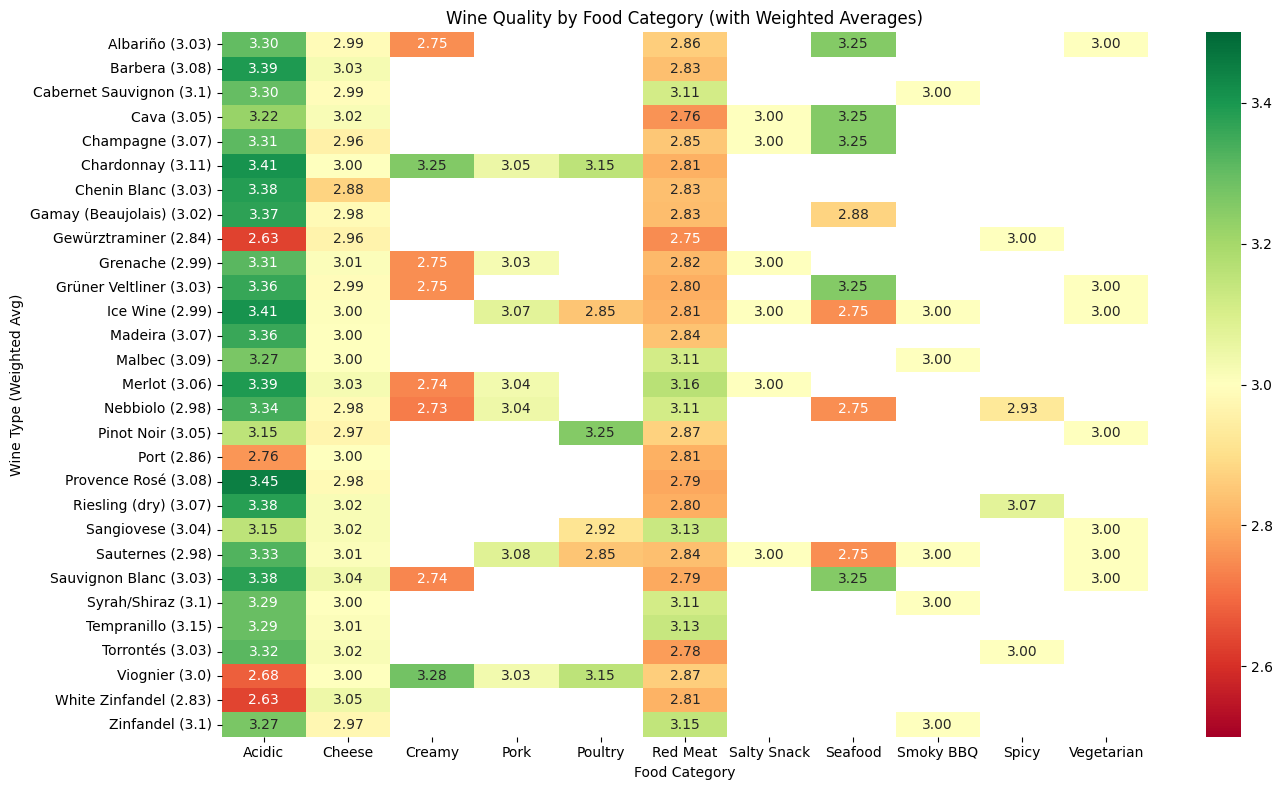

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# First, get the heatmap data
query = """
SELECT
    wine_type,
    food_category,
    AVG(pairing_quality) as avg_quality
FROM wine_pairings
WHERE food_category != 'Dessert'
GROUP BY wine_type, food_category
"""
heatmap_data = pd.read_sql(query, conn)

# Create pivot table
pivot_table = heatmap_data.pivot(index='wine_type', columns='food_category', values='avg_quality')

# Calculate weighted average for each wine type (average of the averages)
weighted_avg = pivot_table.mean(axis=1).round(2)

# Create new labels with weighted average
new_labels = [f"{wine} ({weighted_avg[wine]})" for wine in pivot_table.index]

# Create heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', center=3, vmin=2.5, vmax=3.5, yticklabels=new_labels)
plt.title('Wine Quality by Food Category (with Weighted Averages)')
plt.xlabel('Food Category')
plt.ylabel('Wine Type (Weighted Avg)')
plt.tight_layout()
plt.show()